In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!pip install git+https://github.com/amazon-science/chronos-forecasting.git
!pip install pandas torch matplotlib numpy pyarrow fastparquet peft

  Cloning https://github.com/amazon-science/chronos-forecasting.git to /tmp/pip-req-build-ybo1k3gh
  Running command git clone --filter=blob:none --quiet https://github.com/amazon-science/chronos-forecasting.git /tmp/pip-req-build-ybo1k3gh
  Resolved https://github.com/amazon-science/chronos-forecasting.git to commit f889ae66477b53f6beb130f5c7b13590b29a1035
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
!unzip  /content/multimodal_checkpoints_dim_8_batch_32.zip

Archive:  /content/multimodal_checkpoints_dim_8_batch_32.zip
   creating: content/multimodal_checkpoints/
  inflating: content/multimodal_checkpoints/train_log_dim_8.txt  
   creating: content/multimodal_checkpoints/chronos_lora_adapter/
  inflating: content/multimodal_checkpoints/chronos_lora_adapter/adapter_config.json  
  inflating: content/multimodal_checkpoints/chronos_lora_adapter/README.md  
  inflating: content/multimodal_checkpoints/chronos_lora_adapter/adapter_model.safetensors  
  inflating: content/multimodal_checkpoints/vision_projector.pth  


In [ ]:
!zip -r /content/multimodal_checkpoints_dim_16_batch_16_acc_2_FIX.zip /content/multimodal_checkpoints_dim_16_batch_16_acc_2_FIX

  adding: content/multimodal_checkpoints_dim_16_batch_16_acc_2_FIX/ (stored 0%)
  adding: content/multimodal_checkpoints_dim_16_batch_16_acc_2_FIX/chronos_lora_adapter/ (stored 0%)
  adding: content/multimodal_checkpoints_dim_16_batch_16_acc_2_FIX/chronos_lora_adapter/adapter_config.json (deflated 59%)
  adding: content/multimodal_checkpoints_dim_16_batch_16_acc_2_FIX/chronos_lora_adapter/README.md (deflated 66%)
  adding: content/multimodal_checkpoints_dim_16_batch_16_acc_2_FIX/chronos_lora_adapter/adapter_model.safetensors (deflated 7%)
  adding: content/multimodal_checkpoints_dim_16_batch_16_acc_2_FIX/vision_projector.pth (deflated 24%)


In [ ]:
import torch.nn as nn
from transformers import AutoModel, AutoImageProcessor
from chronos.chronos2.model import Chronos2Model
import torch
from torch.utils.data import Dataset
import pandas as pd
import numpy as np
import io
from torch.utils.data import DataLoader
from peft import LoraConfig, get_peft_model, TaskType
import os
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
from transformers import AutoModel
from peft import PeftModel
from chronos import BaseChronosPipeline

Loading data from /content/drive/MyDrive/FM_project/dataset/skippd_train_embeddings.parquet...
 Automatically identified 3 covariates: ['time_hour_sin', 'time_hour_cos', 'time_dayofyear_sin']
Using precomputed embeddings. Skipping Vision Backbone load.
Base model loaded.
Loading Vision Projector from /content/multimodal_checkpoints_dim_16_batch_16/vision_projector.pth...
Projecting visual embeddings to covariates...
Added 16 covariate columns.
Splitting data for 3 time series...
Train shape: (18379, 6)
Inference/Test shape: (288, 5)
Splitting data for 3 time series...
Train shape: (18379, 22)
Inference/Test shape: (288, 21)
Generating plots for 3 items...


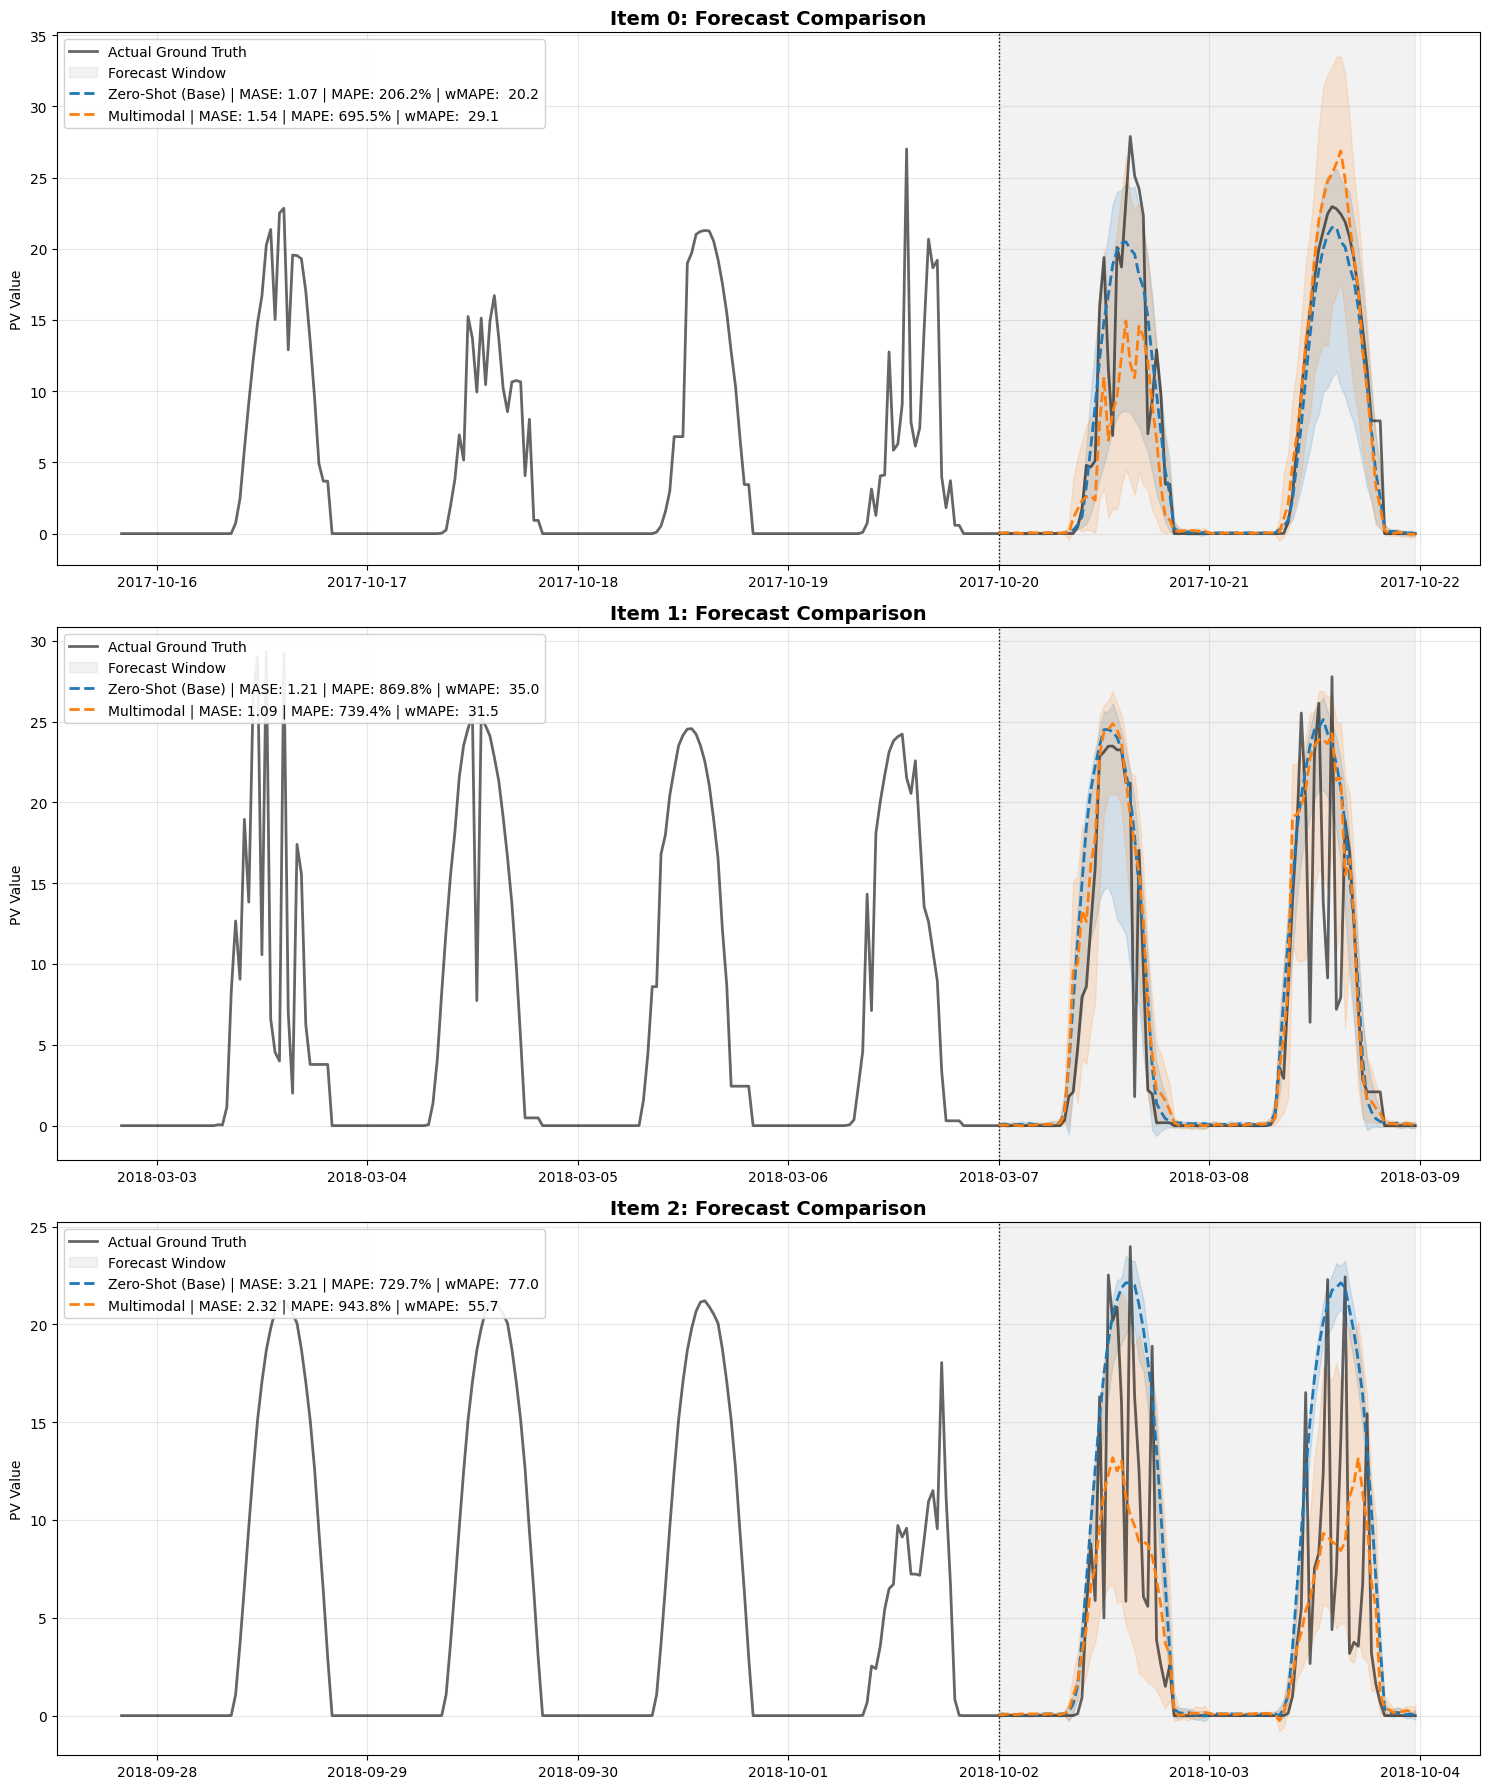

# TRY RETRAINING

In [ ]:
class VisionProjector(nn.Module):
    def __init__(self, input_dim=384, output_dim=16, hidden_dim=128):
        """
        Projects high-dimensional visual features (from DinoV2) into
        low-dimensional 'synthetic covariates' for Chronos.
        """
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(), # Better than ReLU for VIT features usually
            nn.Linear(hidden_dim, output_dim),
            nn.BatchNorm1d(output_dim) # Ensure output scaling is roughly N(0,1) for Chronos
        )

    def forward(self, x):
        return self.net(x)

class MultimodalChronos(nn.Module):
    def __init__(
        self,
        chronos_model_name="amazon/chronos-2",
        vision_model_name="facebook/dinov2-small",
        covariate_dim=16,
        freeze_vision=True,
        use_precomputed_embeddings=True # New flag
    ):
        super().__init__()
        self.covariate_dim = covariate_dim
        self.use_precomputed = use_precomputed_embeddings

        # 1. The "Eye" (Vision Backbone)
        if not self.use_precomputed:
            print(f"Loading Vision Backbone: {vision_model_name}")
            self.vision_backbone = AutoModel.from_pretrained(vision_model_name)
            if freeze_vision:
                for param in self.vision_backbone.parameters():
                    param.requires_grad = False
            vision_dim = self.vision_backbone.config.hidden_size
        else:
            print("Using precomputed embeddings. Skipping Vision Backbone load.")
            self.vision_backbone = None
            # Assume DinoV2 Small dim if precomputed
            vision_dim = 384

        # 2. The "Translator" (Projector)
        self.projector = VisionProjector(input_dim=vision_dim, output_dim=covariate_dim)

        # 3. The "Brain" (Chronos 2)
        self.chronos = None

    def forward(
        self,
        context_tensor,        # (Batch, Time)
        pixel_values,          # (Batch, Total_Time, C, H, W) OR (Batch, Total_Time, Emb_Dim) if precomputed
        tabular_covariates=None, # (Batch, Total_Time, Num_Covs)
        group_ids=None,
        future_target=None
    ):
        batch_size = pixel_values.shape[0]
        device = context_tensor.device

        # --- A. Process Images (The "Eye") ---
        # ... (Same as before) ...
        if self.use_precomputed:
            raw_embeddings = pixel_values.reshape(-1, pixel_values.shape[-1])
        else:
            _, _, c, h, w = pixel_values.shape
            flat_images = pixel_values.reshape(-1, c, h, w)
            with torch.no_grad():
                vision_outputs = self.vision_backbone(pixel_values=flat_images)
                raw_embeddings = vision_outputs.last_hidden_state[:, 0, :]

        # --- B. Project to Covariates (The "Translator") ---
        visual_flat = self.projector(raw_embeddings)
        visual_seq = visual_flat.reshape(batch_size, -1, self.covariate_dim)

        # Split Visual Sequence into Context and Future
        context_len = context_tensor.shape[1]
        visual_context = visual_seq[:, :context_len, :]

        pred_len = 0
        visual_future = None
        if future_target is not None:
            pred_len = future_target.shape[1]
            visual_future = visual_seq[:, context_len : context_len+pred_len, :]

        # --- C. Process Tabular Covariates ---
        tab_context = None
        tab_future = None
        if tabular_covariates is not None:
            # tabular_covariates is (Batch, Total_Time, Num_Tabular)
            tab_context = tabular_covariates[:, :context_len, :]

            if future_target is not None:
                tab_future = tabular_covariates[:, context_len : context_len+pred_len, :]

        # --- D. Expand Batch for Group Attention ---
        # Order: [PV, Tabular, Visual]

        pv_context_expanded = context_tensor.unsqueeze(1) # (B, 1, T)

        tensors_to_cat = [pv_context_expanded]

        if tab_context is not None:
            # (B, T, Num_Tab) -> (B, Num_Tab, T)
            tensors_to_cat.append(tab_context.permute(0, 2, 1))

        tensors_to_cat.append(visual_context.permute(0, 2, 1)) # (B, Cov_Dim, T)

        combined_context = torch.cat(tensors_to_cat, dim=1)

        if future_target is not None:
            pv_future_expanded = future_target.unsqueeze(1)
            future_to_cat = [pv_future_expanded]

            if tab_future is not None:
                future_to_cat.append(tab_future.permute(0, 2, 1))

            future_to_cat.append(visual_future.permute(0, 2, 1))

            combined_future = torch.cat(future_to_cat, dim=1)

        # Update num_series to include Tabular dims
        # combined_context is (Batch, Total_Series, T)
        num_series = combined_context.shape[1]

        flat_context = combined_context.reshape(-1, context_len)

        flat_future_target = None
        if future_target is not None:
            flat_future_target = combined_future.reshape(-1, pred_len)

        ids = torch.arange(batch_size, device=device).unsqueeze(1).repeat(1, num_series).flatten()

        if future_target is not None:
            sample_mask = torch.zeros((num_series, pred_len), dtype=torch.bool, device=device)
            sample_mask[0, :] = True
            flat_mask = sample_mask.unsqueeze(0).repeat(batch_size, 1, 1).reshape(-1, pred_len)
        else:
            flat_mask = None

        # --- D. Forward Pass ---
        output_patch_size = 16
        num_output_patches = 1
        if future_target is not None:
             import math
             pred_len = future_target.shape[1]
             num_output_patches = math.ceil(pred_len / output_patch_size)

        outputs = self.chronos(
            context=flat_context,
            group_ids=ids,
            future_target=flat_future_target,
            future_target_mask=flat_mask,
            num_output_patches=num_output_patches
        )

        return outputs


In [ ]:
class MultimodalDataset(Dataset):
    def __init__(self, df, prediction_length, context_length, image_processor=None, mode="train", use_precomputed=False, stride=1):
        self.df = df
        self.prediction_length = prediction_length
        self.context_length = context_length
        self.image_processor = image_processor
        self.mode = mode
        self.use_precomputed = use_precomputed
        self.stride = stride

        # --- Optimization: Convert Dataframes to Tensors once ---
        # We need to map (item_id, local_index) -> global_index to slice correctly
        # Or even simpler: we just iterate the series, extract their data, and store a list of Tensors (one per series).

        self.series_data = {} # item_id -> { "pv": Tensor, "emb": Tensor }

        # Group by series_id
        grouped = self.df.groupby('item_id')

        # Create samples index
        self.samples = []

        print("Preprocessing dataset into tensors for speed...")
        for s_id, group in grouped:
            # Extract PV values as Float Tensor
            pv_values = torch.tensor(group['pv_value'].values, dtype=torch.float32)

            # Extract Embeddings
            embeddings = None
            images_list = None

            if use_precomputed:
                # Fast track: Stack all embeddings for this series at once
                # This is the slow operation, but we do it ONLY ONCE here.
                emb_list = group['visual_embedding'].values
                # Assuming emb_list is array of lists/arrays.
                # np.stack might still be slow if len is huge, but it's done once.
                # Note: np.vstack might be safer if shapes vary, but they shouldn't.
                embeddings = torch.tensor(np.stack(emb_list), dtype=torch.float32)

            else:
                 images_list = group['image'].values # Keep as list of bytes/dicts


            # Extract Tabular Covariates (e.g., time_hour_sin, etc.)
            # Identify columns that are NOT 'pv_value', 'visual_embedding', 'image', 'item_id', 'timestamp', 'time'
            excluded_cols = ['pv_value', 'visual_embedding', 'image', 'item_id', 'timestamp', 'time', 'series_id']
            cov_cols = [c for c in group.columns if c not in excluded_cols]

            # Sort cov_cols to ensure deterministic order (e.g., alphabetical)
            # This order MUST match inference/visualization time!
            # In visualization: COVARIATE_COLUMNS (from df minus reserved) + cov_cols (visual)
            # Assuming COVARIATE_COLUMNS are these tabular ones.
            # We should probably pass the list of cov_cols explicitly to be safe, but sorting is a good default.
            cov_cols.sort()

            if cov_cols:
                # (Length, Num_Covs)
                tabular_covs = torch.tensor(group[cov_cols].values, dtype=torch.float32)
            else:
                tabular_covs = None

            # Store in cached dict
            self.series_data[s_id] = {
                "pv": pv_values,
                "emb": embeddings,
                "img": images_list,
                "tab": tabular_covs,
                "cov_names": cov_cols
            }

            series_len = len(group)

            # Generate Sample Indices
            if mode == "train":
                if series_len > context_length + prediction_length:
                    for i in range(0, series_len - context_length - prediction_length + 1, self.stride):
                         self.samples.append((s_id, i))
            else:
                if series_len >= context_length:
                    self.samples.append((s_id, series_len - context_length))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s_id, start_idx = self.samples[idx]

        series = self.series_data[s_id]

        # Slice ranges
        total_len = self.context_length + (self.prediction_length if self.mode == "train" else 0)
        end_idx = start_idx + total_len

        # 1. PV Values (Instant Tensor Slice)
        pv_slice = series["pv"][start_idx : end_idx]

        context = pv_slice[:self.context_length]
        future_target = pv_slice[self.context_length:] if self.mode=="train" else None

        if self.use_precomputed:
             # Instant Tensor Slice
             pixel_values = series["emb"][start_idx : end_idx]
        else:
            # Load Images (Legacy Slow Path)
            # We access the raw list of bytes/dicts stored in 'img'
            images_raw = series["img"][start_idx : end_idx]
            images = []

            for img_data in images_raw:
                try:
                    if isinstance(img_data, dict) and 'bytes' in img_data:
                        image = Image.open(io.BytesIO(img_data['bytes'])).convert("RGB")
                    elif isinstance(img_data, bytes):
                        image = Image.open(io.BytesIO(img_data)).convert("RGB")
                    else:
                        image = Image.new('RGB', (224, 224))
                except:
                     image = Image.new('RGB', (224, 224))
                images.append(image)

            # Processor
            if self.image_processor:
                encoding = self.image_processor(images, return_tensors="pt")
                pixel_values = encoding.pixel_values
            else:
                pixel_values = torch.zeros((total_len, 3, 224, 224))

        # 3. Tabular Covariates
        tabular_covariates = None
        if series["tab"] is not None:
            # (Total_Len, Num_Covs)
            tabular_covariates = series["tab"][start_idx : end_idx]

        return {
            "context": context,
            "future_target": future_target,
            "pixel_values": pixel_values,
            "tabular_covariates": tabular_covariates
        }

def collate_fn(batch):
    # Custom collate because items are Tensors of different lengths (if we had varying lengths),
    # but here they are fixed.
    # Just stack them.

    contexts = torch.stack([item['context'] for item in batch])
    pixel_values = torch.stack([item['pixel_values'] for item in batch])

    if batch[0]['future_target'] is not None:
        future_targets = torch.stack([item['future_target'] for item in batch])
    else:
        future_targets = None

    if batch[0]['tabular_covariates'] is not None:
        tabular_covariates = torch.stack([item['tabular_covariates'] for item in batch])
    else:
        tabular_covariates = None

    return {
        "context": contexts,
        "pixel_values": pixel_values,
        "future_target": future_targets,
        "tabular_covariates": tabular_covariates
    }


In [ ]:
# --- Configuration ---
DATA_PATH = r"/content/drive/MyDrive/FM_project/dataset/skippd_train_embeddings.parquet"
OUTPUT_PATH = r"/content/multimodal_checkpoints_dim_16_batch_16/vision_projector_pca_init.pth"
COVARIATE_DIM = 16
HIDDEN_DIM = 128

def main():
    print(f"Loading data from {DATA_PATH}...")
    df = pd.read_parquet(DATA_PATH)

    # Extract all embeddings
    # df['visual_embedding'] is column of arrays/lists
    print("Stacking embeddings...")
    embeddings_list = np.stack(df['visual_embedding'].values) # (N_Samples, 384)
    # Note: These are 'per timestamp' embeddings if original data was per-timestamp.
    # If the dataframe has time steps, we have N rows.

    X = embeddings_list
    print(f"Data shape: {X.shape}")

    # Compute PCA
    print(f"Fitting PCA with {COVARIATE_DIM} components...")
    pca = PCA(n_components=COVARIATE_DIM)
    pca.fit(X)

    components = pca.components_ # (n_components, n_features) -> (16, 384)
    mean = pca.mean_             # (384,)

    print("PCA Components shape:", components.shape)

    # Initialize Projector
    print("Initializing VisionProjector...")
    projector = VisionProjector(input_dim=384, output_dim=COVARIATE_DIM, hidden_dim=HIDDEN_DIM)

    # --- Weight Initialization Strategy ---
    # We want Projector(x) ~ PCA(x)
    # PCA(x) = (x - mean) @ V.T
    # Projector uses MLP: Linear -> BN -> GELU -> Linear -> BN

    # Strategy:
    # W1 (Hidden) captures PCA directions.
    # W2 (Output) passes them through.

    with torch.no_grad():
        # 1. First Linear Layer (384 -> 128)
        # We place the 16 PCA components into the first 16 rows of W1
        # The rest can be random or zero.

        # W1 is (128, 384)
        w1 = projector.net[0].weight
        b1 = projector.net[0].bias

        # Zero out first
        w1.zero_()
        b1.zero_()

        # Copy PCA components into first COVARIATE_DIM slots
        # components is (16, 384). w1[:16] is (16, 384).
        w1[:COVARIATE_DIM] = torch.tensor(components, dtype=torch.float32)

        # Bias: We need to subtract the mean.
        # Linear layer computes x @ W.T + b
        # PCA computes (x - mean) @ V.T = x @ V.T - mean @ V.T
        # So bias b = - (mean @ V.T)

        pca_bias = - np.dot(mean, components.T) # (16,)
        b1[:COVARIATE_DIM] = torch.tensor(pca_bias, dtype=torch.float32)

        # 2. BatchNorm 1 (128)
        # Initialize to identity-like
        bn1 = projector.net[1]
        bn1.weight.fill_(1.0)
        bn1.bias.zero_()

        # 3. Second Linear Layer (128 -> 16)
        # We want to select the first 16 dimensions and pass them to output.
        # W2 is (16, 128)
        w2 = projector.net[3].weight
        b2 = projector.net[3].bias

        w2.zero_()
        b2.zero_()

        # Make the top-left (16, 16) block Identity
        # So it takes the 16 PCA features created in Layer 1 and passes them.
        for i in range(COVARIATE_DIM):
            w2[i, i] = 1.0

        # 4. BatchNorm 2 (16)
        bn2 = projector.net[4]
        bn2.weight.fill_(1.0)
        bn2.bias.zero_()

    print("Projector weights initialized with PCA + Identity pass-through.")

    # Save
    os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)
    torch.save(projector.state_dict(), OUTPUT_PATH)
    print(f"Saved initialized projector to {OUTPUT_PATH}")

if __name__ == "__main__":
    main()


In [ ]:
BASE_DIR = "/content/drive/MyDrive/FM_project/dataset"
DATA_PATH = os.path.join(BASE_DIR,"skippd_train_embeddings.parquet")
OUTPUT_DIR = "/content/ckp_dim_16_batch_16_acc_2_FIX_DoRA_20_epochs_ctx_336"
VISION_MODEL = "facebook/dinov2-small"
CHRONOS_MODEL = "amazon/chronos-2"
BATCH_SIZE = 16
GRADIENT_ACCUMULATION_STEPS = 2
LEARNING_RATE = 1e-4
NUM_EPOCHS = 20
CONTEXT_LENGTH = 336
PREDICTION_LENGTH = 96
COVARIATE_DIM = 16
STRIDE = 4 # 12 hours between samples (48 steps/day)

In [ ]:

def load_data(path):
    print(f"Loading dataset from {path}...")
    df = pd.read_parquet(path)

    # Ensuring timestamp sorting etc.
    if 'time' in df.columns and 'timestamp' not in df.columns:
        df['timestamp'] = pd.to_datetime(df['time'])
        if df['timestamp'].dt.tz is not None:
             df['timestamp'] = df['timestamp'].dt.tz_localize(None)

    # Rename for consistency with Dataset class expectations
    # Check if we need to rename (precomputed file might have 'series_id' and 'pv')
    if "series_id" in df.columns:
        df = df.rename(columns={"series_id": "item_id", "pv": "pv_value"})

    df = df.sort_values(['item_id', 'timestamp']).reset_index(drop=True)
    return df

def main():
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")

    # 1. Prepare Data
    df = load_data(DATA_PATH)

    # Dataset
    # image_processor is not needed if using precomputed embeddings
    dataset = MultimodalDataset(
        df=df,
        prediction_length=PREDICTION_LENGTH,
        context_length=CONTEXT_LENGTH,
        image_processor=None,
        mode="train",
        use_precomputed=True,
        stride=STRIDE
    )

    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn, num_workers=2)
    print(f"Dataset created with {len(dataset)} samples.")

    # 2. Prepare Model
    model = MultimodalChronos(
        chronos_model_name=CHRONOS_MODEL,
        vision_model_name=VISION_MODEL,
        covariate_dim=COVARIATE_DIM,
        freeze_vision=True,
        use_precomputed_embeddings=True
    )

    # Load PCA Initialization if available
    pca_init_path = os.path.join(OUTPUT_DIR, "vision_projector_pca_init.pth")
    if os.path.exists(pca_init_path):
        print(f"Loading PCA-Initialized Projector from {pca_init_path}...")
        model.projector.load_state_dict(torch.load(pca_init_path))
    else:
        print("No PCA initialization found. Training projector from scratch (Random Init).")

    # Load Chronos part correctly
    from chronos import BaseChronosPipeline
    print("Loading Chronos Pipeline to get model...")
    pipeline = BaseChronosPipeline.from_pretrained(CHRONOS_MODEL, device_map=device, torch_dtype=torch.bfloat16)
    model.chronos = pipeline.model

    # Explicitly cast Vision Backbone to bfloat16 to save memory (it's frozen anyway)
    # print("Casting Vision Backbone to bfloat16 to save memory...")
    # if model.vision_backbone is not None:
    #     model.vision_backbone.to(dtype=torch.bfloat16)

    # Also cast the Projector to bfloat16 to match the incoming embeddings
    print("Casting Projector to bfloat16...")
    model.projector.to(dtype=torch.bfloat16)

    # Move entire fusion model to device
    model.to(device)

    peft_config = LoraConfig(
        r=16,                    # Rank (same as default or adjust as needed)
        lora_alpha=32,           # Alpha (scaling factor)
        target_modules=[
            "self_attention.q",
            "self_attention.v",
            "self_attention.k",
            "self_attention.o",
            "output_patch_embedding.output_layer",
        ],
        lora_dropout=0.05,
        bias="none",
        #task_type="CAUSAL_LM",
        use_dora=True
    )
    """
    # Apply LoRA to Chronos
    peft_config = LoraConfig(
        inference_mode=False,
        r=8,
        lora_alpha=32,
        lora_dropout=0.1,
        target_modules=[
            "self_attention.q",
            "self_attention.v",
            "self_attention.k",
            "self_attention.o",
            "output_patch_embedding.output_layer",
        ],
    )
    """
    # We wrap just the chronos component
    model.chronos = get_peft_model(model.chronos, peft_config)
    model.chronos.print_trainable_parameters()

    # 3. Optimizer
    trainable_params = [p for p in model.projector.parameters()] + \
                       [p for p in model.chronos.parameters() if p.requires_grad]

    optimizer = torch.optim.AdamW(trainable_params, lr=LEARNING_RATE)

    # 4. Training Loop
    model.train()
    print("Starting Training...")

    for epoch in range(NUM_EPOCHS):
        total_loss = 0
        steps = 0
        optimizer.zero_grad()

        for i, batch in enumerate(dataloader):
            # Move data to device and cast to bfloat16
            context = batch["context"].to(device).bfloat16()
            pixel_values = batch["pixel_values"].to(device).bfloat16()
            future_target = batch["future_target"].to(device).bfloat16()

            tabular_covariates = None
            if batch["tabular_covariates"] is not None:
                tabular_covariates = batch["tabular_covariates"].to(device).bfloat16()

            # Forward
            outputs = model(
                context_tensor=context,
                pixel_values=pixel_values,
                tabular_covariates=tabular_covariates,
                future_target=future_target
            )

            # Loss calculation
            loss = outputs.loss if hasattr(outputs, "loss") else None

            if loss is None:
                print("Warning: Model didn't return loss. Check implementation.")
                break

            # Normalize loss for gradient accumulation
            loss = loss / GRADIENT_ACCUMULATION_STEPS
            loss.backward()

            if (i + 1) % GRADIENT_ACCUMULATION_STEPS == 0:
                optimizer.step()
                optimizer.zero_grad()

            # Scale back for logging
            current_loss = loss.item() * GRADIENT_ACCUMULATION_STEPS
            total_loss += current_loss
            steps += 1

            # Aggressive cleanup
            del context, pixel_values, future_target, outputs, loss

            if steps % 10 == 0:
                print(f"Epoch {epoch+1} | Step {steps} | Loss: {current_loss:.4f}")
                # Optional: empty cache if really tight
                # torch.cuda.empty_cache()

        print(f"Epoch {epoch+1} Complete. Avg Loss: {total_loss/steps:.4f}")

    # 5. Save
    print("Saving Projector and Adapter...")
    torch.save(model.projector.state_dict(), os.path.join(OUTPUT_DIR, "vision_projector.pth"))
    model.chronos.save_pretrained(os.path.join(OUTPUT_DIR, "chronos_dora_adapter"))
    print("Done!")

if __name__ == "__main__":
    main()


Using device: cuda
Loading dataset from /content/drive/MyDrive/FM_project/dataset/skippd_train_embeddings.parquet...
Preprocessing dataset into tensors for speed...
Dataset created with 4453 samples.
Using precomputed embeddings. Skipping Vision Backbone load.
No PCA initialization found. Training projector from scratch (Random Init).
Loading Chronos Pipeline to get model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
`torch_dtype` is deprecated! Use `dtype` instead!
`torch_dtype` is deprecated! Use `dtype` instead!


Casting Projector to bfloat16...
trainable params: 1,206,912 || all params: 120,684,576 || trainable%: 1.0001
Starting Training...
Epoch 1 | Step 10 | Loss: 0.0559
Epoch 1 | Step 20 | Loss: 0.0625
Epoch 1 | Step 30 | Loss: 0.0710
Epoch 1 | Step 40 | Loss: 0.0869
Epoch 1 | Step 50 | Loss: 0.1112
Epoch 1 | Step 60 | Loss: 0.0677
Epoch 1 | Step 70 | Loss: 0.0737
Epoch 1 | Step 80 | Loss: 0.0561
Epoch 1 | Step 90 | Loss: 0.0995
Epoch 1 | Step 100 | Loss: 0.0881
Epoch 1 | Step 110 | Loss: 0.0867
Epoch 1 | Step 120 | Loss: 0.0720
Epoch 1 | Step 130 | Loss: 0.0666
Epoch 1 | Step 140 | Loss: 0.0615
Epoch 1 | Step 150 | Loss: 0.0586
Epoch 1 | Step 160 | Loss: 0.0596
Epoch 1 | Step 170 | Loss: 0.0540
Epoch 1 | Step 180 | Loss: 0.0618
Epoch 1 | Step 190 | Loss: 0.0575
Epoch 1 | Step 200 | Loss: 0.0811
Epoch 1 | Step 210 | Loss: 0.0502
Epoch 1 | Step 220 | Loss: 0.0625
Epoch 1 | Step 230 | Loss: 0.0495
Epoch 1 | Step 240 | Loss: 0.0854
Epoch 1 | Step 250 | Loss: 0.0961
Epoch 1 | Step 260 | Loss: 0

Loading data from /content/drive/MyDrive/FM_project/dataset/skippd_train_embeddings.parquet...
 Automatically identified 3 covariates: ['time_hour_sin', 'time_hour_cos', 'time_dayofyear_sin']
Using precomputed embeddings. Skipping Vision Backbone load.
Base model loaded.
Loading Vision Projector from /content/multimodal_checkpoints_dim_16_batch_16_acc_2_FIX/vision_projector.pth...
Projecting visual embeddings to covariates...
Added 16 covariate columns.
Splitting data for 3 time series...
Train shape: (18379, 6)
Inference/Test shape: (288, 5)
Splitting data for 3 time series...
Train shape: (18379, 22)
Inference/Test shape: (288, 21)
Generating plots for 3 items...


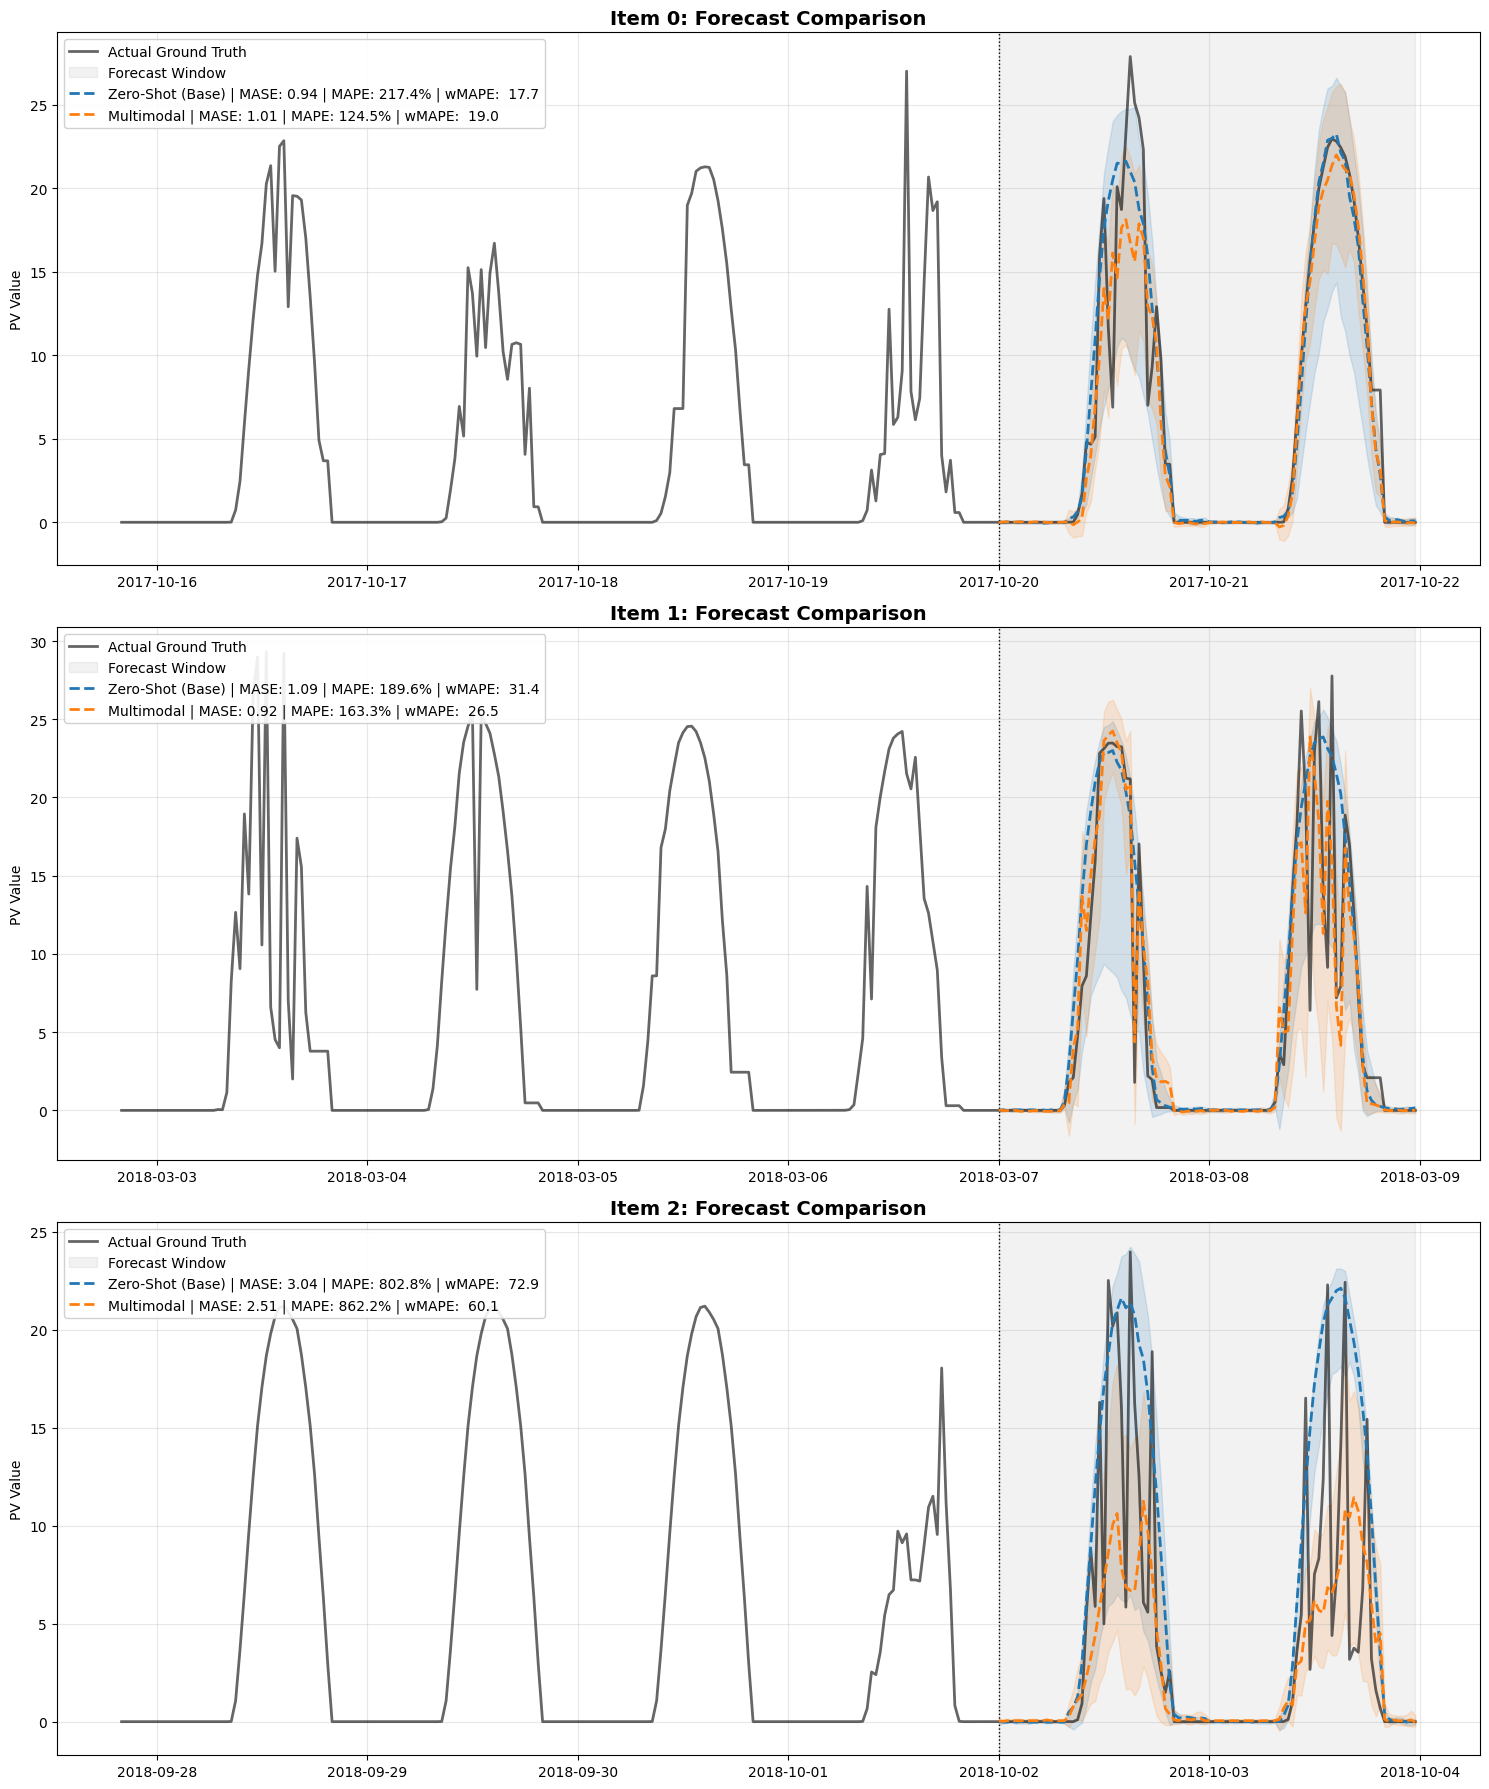

In [ ]:


# --- Configuration ---
BASE_DIR = "/content/drive/MyDrive/FM_project/dataset"
DATA_PATH = os.path.join(BASE_DIR,"skippd_train_embeddings.parquet")
#CHECKPOINT_DIR = "/content/multimodal_checkpoints_dim_16_batch_16_acc_2_FIX"
#CHECKPOINT_DIR = "/content/multimodal_checkpoints_dim_8_batch_32"
CHECKPOINT_DIR = "/content/ckp_dim_16_batch_16_acc_2_FIX_DoRA_20_epochs_ctx_336"
#checkpoint_path="/content/multimodal_checkpoints_dim_16_batch_16_acc_2_FIX/chronos_lora_adapter"
#checkpoint_path="/content/multimodal_checkpoints_dim_8_batch_32/chronos_lora_adapter"
checkpoint_path = "/content/ckp_dim_16_batch_16_acc_2_FIX_DoRA_20_epochs_ctx_336/chronos_dora_adapter"
VISION_MODEL = "facebook/dinov2-small"
CHRONOS_MODEL = "amazon/chronos-2"
CONTEXT_LENGTH = 192
PREDICTION_LENGTH = 96
prediction_length = PREDICTION_LENGTH
COVARIATE_DIM = 16
target = "pv_value"
id_column = "item_id"
timestamp_column = "timestamp"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


def load_ft_chronos_model():
    model = MultimodalChronos(
        chronos_model_name=CHRONOS_MODEL,
        vision_model_name=VISION_MODEL,
        covariate_dim=COVARIATE_DIM,
        freeze_vision=True,
        use_precomputed_embeddings=True
    )

    # 2. Load the Base Model
    pipeline = BaseChronosPipeline.from_pretrained(
        CHRONOS_MODEL,
        device_map="cuda",
        torch_dtype=torch.bfloat16
    )

    print("Base model loaded.")

    # 3. Attach your LoRA/DoRA Adapter
    pipeline.model = PeftModel.from_pretrained(
        pipeline.model,
        checkpoint_path
    )

    # Load Projector Weights
    projector_path = os.path.join(CHECKPOINT_DIR, "vision_projector.pth")
    if os.path.exists(projector_path):
        print(f"Loading Vision Projector from {projector_path}...")
        state_dict = torch.load(projector_path)
        model.projector.load_state_dict(state_dict)
    else:
        print("Warning: Vision Projector weights not found!")

    # Cast Projector and Move
    model.projector.to(dtype=torch.bfloat16)
    model.to(DEVICE)
    model.eval()

    return model, pipeline


# --- 2. Feature Engineering ---
@torch.no_grad()
def add_projected_features(df, projector):
    """
    Takes the dataframe with 384-dim embeddings.
    Runs the projector.
    Adds 16 columns 'cov_0'...'cov_15' to the dataframe.
    """
    print("Projecting visual embeddings to covariates...")

    all_embeddings = np.stack(df['visual_embedding'].values) # (N, 384)
    all_tensor = torch.tensor(all_embeddings, dtype=torch.bfloat16, device=DEVICE)


    # Project
    # (N, 16)
    projected_tensor = projector.projector(all_tensor)
    projected_np = projected_tensor.float().cpu().numpy()

    # Add to DataFrame
    cov_cols = [f"cov_{i}" for i in range(projector.covariate_dim)]

    # Create a DataFrame of new cols
    cov_df = pd.DataFrame(projected_np, columns=cov_cols, index=df.index)

    # Concatenate
    df_enriched = pd.concat([df, cov_df], axis=1)

    return df_enriched, cov_cols

def predict(pipeline, train_df, inference_df, test_df, context_length, prediction_length, cov_cols):
    pred_df = pipeline.predict_df(
        df=train_df,
        future_df=inference_df,
        context_length=context_length,
        prediction_length=prediction_length,
        quantile_levels=[0.1, 0.5, 0.9],
        id_column=id_column,
        timestamp_column=timestamp_column,
        target=target,
    )

    return pred_df



# --- Metric & Plotting (Same as before) ---
def calculate_item_mase(y_true, y_pred, y_history, seasonality=96):
    """Calculates MASE for a single item."""
    # Mean Absolute Error of the forecast
    forecast_mae = np.mean(np.abs(y_true - y_pred))

    # Mean Absolute Error of the naive baseline on history
    # (comparing t with t-seasonality)
    if len(y_history) <= seasonality:
        return np.inf # Not enough history for seasonality

    naive_errors = np.abs(y_history[seasonality:] - y_history[:-seasonality])
    naive_mae = np.mean(naive_errors)

    if naive_mae == 0:
        return np.inf

    return forecast_mae / naive_mae

def calculate_item_mape(y_true, y_pred, epsilon=1e-10):
    """
    Calculates Mean Absolute Percentage Error (MAPE).

    Args:
        epsilon (float): Small value to avoid division by zero.
                         Alternatively, you can mask values where y_true == 0.
    """
    # Option A: Add epsilon to avoid zero division (simplest)
    # mape = np.mean(np.abs((y_true - y_pred) / (y_true + epsilon))) * 100

    # Option B: Filter out zeros (standard for PV data)
    # We only compute MAPE when actual production > 0
    mask = y_true > epsilon
    if np.sum(mask) == 0:
        return np.nan # No valid data points (e.g., essentially night time)

    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    return mape

def calculate_item_wmape(y_true, y_pred):
    """
    Calculates Weighted Mean Absolute Percentage Error (wMAPE).
    This is preferred for intermittent series (like Solar) where y_true can be ~0.
    """
    total_abs_error = np.sum(np.abs(y_true - y_pred))
    total_actuals = np.sum(np.abs(y_true))

    if total_actuals == 0:
        return np.inf

    return (total_abs_error / total_actuals) * 100

# 2. Main Plotting Function
def plot_model_comparison(train_df, test_df, model_predictions,
                          plot_history_length=200, prediction_length=96, seasonality=96):

    # A. Setup Data
    # Concatenate train and test to get the full timeline for plotting context
    full_data = pd.concat([train_df, test_df]).sort_values(['item_id', 'timestamp'])

    item_ids = sorted(full_data['item_id'].unique())
    num_plots = len(item_ids)

    # Safety check for huge datasets
    if num_plots > 20:
        print(f"Warning: Plotting {num_plots} series will create a very large image.")

    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] # Blue, Orange, Green, Red

    # B. Initialize Figure
    fig, axs = plt.subplots(num_plots, 1, figsize=(15, 6 * num_plots), sharex=False)
    if num_plots == 1: axs = [axs] # Ensure axs is always iterable

    print(f"Generating plots for {num_plots} items...")

    for i, item_id in enumerate(item_ids):
        ax = axs[i]

        # --- C. Prepare Series Data ---
        # Filter data for this specific item
        item_full_data = full_data[full_data['item_id'] == item_id].set_index('timestamp')
        item_test_data = test_df[test_df['item_id'] == item_id].set_index('timestamp')
        item_train_data = train_df[train_df['item_id'] == item_id].set_index('timestamp')

        # 1. History Context (for plotting)
        # We grab the last 'plot_history_length' points from training + the prediction window
        history_context = item_full_data.iloc[-(plot_history_length + prediction_length):]

        # 2. Ground Truth (The actual future)
        ground_truth_future = item_test_data['pv_value']

        # 3. History for Metric (for MASE denominator)
        history_for_metric = item_train_data['pv_value'].values

        # --- D. Plot Background ---
        # Plot the actual values (history + future)
        ax.plot(history_context.index, history_context['pv_value'],
                label='Actual Ground Truth', color='black', linewidth=2, alpha=0.6)

        # Highlight the Forecast Window
        if len(ground_truth_future) > 0:
            cutoff_date = ground_truth_future.index[0]
            ax.axvspan(cutoff_date, ground_truth_future.index[-1], color='gray', alpha=0.1, label="Forecast Window")
            ax.axvline(x=cutoff_date, color='black', linestyle=':', linewidth=1)

        # --- E. Plot Each Model ---
        for idx, (model_name, pred_df_all) in enumerate(model_predictions.items()):
            # Filter predictions for this item
            item_preds = pred_df_all[pred_df_all['item_id'] == item_id].set_index('timestamp')

            if item_preds.empty:
                continue

            # 1. Calculate MASE
            try:
                # Align lengths (take last N points if necessary)
                y_pred = item_preds['predictions'].values[-len(ground_truth_future):]
                y_true = ground_truth_future.values[-len(y_pred):]

                mase_score = calculate_item_mase(
                    y_true=y_true,
                    y_pred=y_pred,
                    y_history=history_for_metric,
                    seasonality=seasonality
                )
                # MAPE (Added)
                mape_score = calculate_item_mape(y_true, y_pred)

                wmape = calculate_item_wmape(y_true, y_pred)

                # Create Label
                metrics_label = f"MASE: {mase_score:.2f} | MAPE: {mape_score:.1f}% | wMAPE: {wmape: .1f}"
            except Exception as e:
                metrics_label = "MASE: N/A"

            # 2. Plot Predictions
            color = colors[idx % len(colors)]
            label_text = f'{model_name} | {metrics_label}'

            # Plot Median (prediction)
            ax.plot(item_preds.index, item_preds['predictions'],
                    label=label_text, color=color, linewidth=2, linestyle='--')

            # Plot Quantiles (if available)
            if '0.1' in item_preds.columns and '0.9' in item_preds.columns:
                ax.fill_between(
                    item_preds.index,
                    item_preds['0.1'],
                    item_preds['0.9'],
                    color=color, alpha=0.15
                )

        # --- F. Final Formatting ---
        ax.set_title(f"Item {item_id}: Forecast Comparison", fontsize=14, fontweight='bold')
        ax.set_ylabel("PV Value")
        ax.legend(loc='upper left', fontsize=10, framealpha=0.9)
        ax.grid(True, alpha=0.3)

    #If figuere already present save with an incremental id
    if os.path.exists(f"forecast_comparison_{item_id}.png"):
        i=1
        while os.path.exists(f"forecast_comparison_{item_id}_{i}.png"):
            i+=1
        plt.savefig(f"forecast_comparison_{item_id}_{i}.png")
    else:
      plt.savefig(f"forecast_comparison_{item_id}.png")



    plt.tight_layout()
    plt.show()

# --- 3. Execute ---




def load_and_prepare_data():
    # 1. Load Data
    print(f"Loading data from {DATA_PATH}...")
    df = pd.read_parquet(DATA_PATH)

    column_mapping = {
        "time": "timestamp",
        "series_id": "item_id",
        "pv": "pv_value"
    }

    df = df.rename(columns={k: v for k, v in column_mapping.items() if k in df.columns})

    if 'time' in df.columns:
        df['timestamp'] = pd.to_datetime(df['time'])
        if df['timestamp'].dt.tz is not None:
             df['timestamp'] = df['timestamp'].dt.tz_localize(None)

    df = df.sort_values(['item_id', 'timestamp'])

    initial_cov=reserved_columns = ['timestamp', 'item_id', 'pv_value']
    # Filter out visual_embedding from covariates list as it is an array column
    COVARIATE_COLUMNS = [col for col in df.columns if col not in reserved_columns and col != 'visual_embedding']

    print(f" Automatically identified {len(COVARIATE_COLUMNS)} covariates: {COVARIATE_COLUMNS}")
    # We don't strictly require missing covariates check here since we just derived them from df.columns
    # but keeping it safe.

    return df, COVARIATE_COLUMNS


def split_ts_dataset(df):
    # --- UPDATED LOGIC FOR MULTIPLE SERIES ---

    # 4. Filter out series that are too short
    # We need at least prediction_length + 1 data point to have a training set
    item_counts = df.groupby('item_id').size()
    valid_items = item_counts[item_counts > PREDICTION_LENGTH].index

    if len(valid_items) < len(item_counts):
        print(f"Dropping {len(item_counts) - len(valid_items)} series that are too short.")
        df = df[df['item_id'].isin(valid_items)].copy()

    # 5. Sort by item_id AND timestamp (Critical for correct splitting)
    df = df.sort_values(['item_id', 'timestamp']).reset_index(drop=True)

    # 6. Global Split
    print(f"Splitting data for {len(valid_items)} time series...")

    # Inference/Test: Grab the last PREDICTION_LENGTH rows for EACH item_id
    test_df = df.groupby('item_id').tail(PREDICTION_LENGTH).copy()

    # Train: Drop the rows that belong to test_df
    # (Since we reset_index above, the indices are unique and safe to use for dropping)
    train_df = df.drop(test_df.index).copy()

    # 7. Create Inference input (Drop target)
    inference_df = test_df.copy()
    if 'pv_value' in inference_df.columns:
        inference_df = inference_df.drop(columns=['pv_value'])

    print(f"Train shape: {train_df.shape}")
    print(f"Inference/Test shape: {inference_df.shape}")

    return train_df, inference_df, test_df


def main():

    df, COVARIATE_COLUMNS = load_and_prepare_data()

    # 2. Load Model
    projector, pipeline = load_ft_chronos_model()

    # 3. Project Features (This matches user's request to "create dataset with feature")
    df_enriched, cov_cols = add_projected_features(df, projector)
    print(f"Added {len(cov_cols)} covariate columns.")

    # FIX: Drop the raw embedding column (numpy arrays) because standard pipeline functions
    # (like predict_df) try to hash/factorize columns and fail on arrays.
    if 'visual_embedding' in df_enriched.columns :
        df_enriched = df_enriched.drop(columns=['visual_embedding'])
    if 'visual_embedding' in df.columns:
        df = df.drop(columns=['visual_embedding'])
    train_df_original, inference_df_original, test_df_original = split_ts_dataset(df)
    pred_df_original = predict(pipeline, train_df_original, inference_df_original, test_df_original, CONTEXT_LENGTH, PREDICTION_LENGTH, COVARIATE_COLUMNS)

    # Use + for list concatenation to create a new list, or use the extended name if modified in place
    # Extending COVARIATE_COLUMNS in place (if it's a list)
    final_cov = COVARIATE_COLUMNS + cov_cols

    train_df, inference_df, test_df = split_ts_dataset(df_enriched)

    # 4. Predict
    pred_df_multimodal = predict(pipeline, train_df, inference_df, test_df, CONTEXT_LENGTH, PREDICTION_LENGTH, final_cov)

    models_to_plot = {
        "Zero-Shot (Base)": pred_df_original,
        "Multimodal": pred_df_multimodal,
    }
    # 5. Visualize
    # Pass df as both train and test since we just sliced from it
    plot_model_comparison(
        train_df=train_df,
        test_df=test_df,
        model_predictions=models_to_plot,
        plot_history_length=200,   # How many historical steps to show before the forecast
        prediction_length=PREDICTION_LENGTH,
        seasonality=96             # Seasonality for MASE (96 steps = 48 hours for 30min data)
    )

if __name__ == "__main__":
    main()


